# Maji Ndogo Water Infrastructure
**Role:** Junior Data Analyst  
**Tools:** MySQL, Python (Jupyter Notebook, %sql magic), optional basic plotting  

**Project Goal:**  
Understand the current water infrastructure and auditor reports to guide prioritisation of repairs and investments.

## CONNECTING THE NOTEBOOK TO MYSQL DATABASE

# MySQL Connection Setup

## Overview
Custom database module (`db_connect.py`) that provides secure, reusable MySQL connection with automatic `%%sql` magic configuration.

## Connection Flow
1. **Import module** → `from db_connect import connect_to_db`
2. **Connect** → `engine, conn = connect_to_db()`
3. **Prompts** → Enter database name and password (hidden)
4. **Auto-config** → SQL magic automatically configured
5. **Use** → `%%sql` works in every cell

## Key Features
- **Secure**: Passwords never stored, hidden input via `getpass`
- **Cached**: Single connection reused across all cells
- **Portable**: Works with any MySQL database
- **Helper functions**: `show_databases()`, `show_tables()`, `describe_table()`

## Usage in Notebook
```python
# First cell - Connect
from db_connect import connect_to_db
engine, conn = connect_to_db()
# Prompts: database name and password

# Any cell after - Use %%sql
%%sql
SELECT * FROM visits LIMIT 5;

# Helper functions
show_tables()           # List tables
describe_table('visits') # Table structure
switch_database('new_db') # Switch databases

In [1]:
from db_connect import connect_to_db

engine, conn = connect_to_db()

Please enter database name:  water_analysis


   Using default: water_analysis


 Please enter the password for root@127.0.0.1:  ········



 The notebook is successfully connected to MYSQL!
  Server: 127.0.0.1:3306
  Database in use: water_analysis
  User: root
SQL magic configured - use %%sql in any cell!


### TABLES AVAILABLE IN THE DATABASE

In [1]:
from db_connect import show_tables

# List all tables in current database
show_tables()

Please enter database name:  water_analysis


   Using default: water_analysis


 Please enter the password for root@127.0.0.1:  ········



 The notebook is successfully connected to MYSQL!
  Server: 127.0.0.1:3306
  Database in use: water_analysis
  User: root
SQL magic configured - use %%sql in any cell!

 Tables in database:
----------------------------------------
   1. auditor_report                 (         0 rows)
   2. data_dictionary                (        49 rows)
   3. employee                       (        56 rows)
   4. global_water_access            (       464 rows)
   5. infastructure                  (    39,650 rows)
   6. location                       (    39,650 rows)
   7. visits                         (    60,146 rows)
   8. water_quality                  (    60,146 rows)
   9. water_source                   (    39,650 rows)
  10. well_pollution                 (    17,383 rows)


,Tables_in_water_analysis
0,auditor_report
1,data_dictionary
2,employee
3,global_water_access
4,infastructure
5,location
6,visits
7,water_quality
8,water_source
9,well_pollution


### Data Model Structure

The `visits` table acts as the central fact table, capturing operational events such as inspection time, queue duration, and assigned personnel. It connects multiple entities including water sources, employees, and locations.

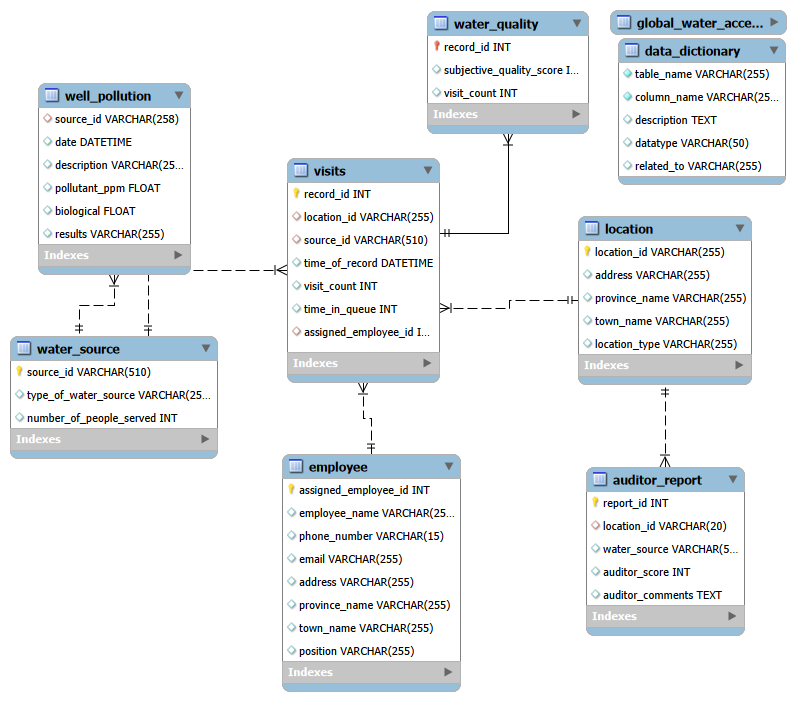

## Primary / Foreign Key Relationships

### Core Structure

- **`visits`** is the central fact table.  
  - `location_id` → foreign key to `location.location_id`  
  - `source_id` → foreign key to `water_source.source_id`  
  - `assigned_employee_id` → foreign key to `employee.assigned_employee_id`

### Supporting Tables

- **`well_pollution`**  
  - `source_id` → foreign key to `water_source.source_id` (one‑to‑many: a well may have multiple pollution tests)

- **`water_quality`**  
  - `record_id` → likely foreign key to `visits.record_id` (connects quality scores to specific visits)

- **`auditor_report`** (imported from CSV)  
  - `location_id` → foreign key to `location.location_id`  
  - `type_of_water_source` can be used to cross‑reference with `water_source.type_of_water_source` (not a strict FK, but useful for validation)

### Primary Keys (Unique Identifiers)

| Table | Primary Key |
|-------|-------------|
| `employee` | `assigned_employee_id` |
| `visits` | `record_id` |
| `location` | `location_id` |
| `water_source` | `source_id` |
| `well_pollution` | composite: (`source_id`, `date`) – not explicitly declared in schema, but logically unique |
| `auditor_report` | no explicit primary key; `location_id` could serve if each location has one audit |

This schema allows joining across tables to analyse water source conditions, queue times, contamination, and auditor findings.

## data dictionary

## Data Sources

| Table            | Purpose                              | Key Columns                                                                 |
|------------------|--------------------------------------|-----------------------------------------------------------------------------|
| water_source     | Types of sources and population served | source_id, type_of_water_source, number_of_people_served                    |
| location         | Geographic context                   | location_id, address, town_name, province_name                              |
| visits           | Operational logs                     | source_id, location_id, time_in_queue, visit_count                          |
| well_pollution   | Water quality tests                  | source_id, results, biological, pollutant_ppm                               |
| auditor_report (CSV) | Third-party validation            | location_id, type_of_water_source, true_water_source_score, statements      |

## Business Question Framework

### Question 1: Infrastructure Failure Impact Analysis

#### Problem Statement
> "What is the total population affected by each type of infrastructure failure, broken down by province, and which province has the highest ratio of affected people to total population?"

#### Business Context
Resource allocation decisions require understanding not just absolute numbers but **proportional impact**. A broken tap affecting 1,000 people in a small town represents a more severe infrastructure crisis than the same number in a large city. This analysis establishes the foundation for evidence-based prioritization of intervention teams.

####  Failure Type Definitions

| Category | Definition | Identification Logic | Data Source |
|----------|------------|---------------------|-------------|
| **Broken Tap** | Non-functional household water connections | `type_of_water_source = 'tap_in_home_broken'` | `water_source` |
| **Contaminated Well** | Water sources with unsafe contamination levels | `results = 'Contaminated'` | `well_pollution` |
| **Long Queue** | Wait times exceeding UN standard | `time_in_queue > 30 minutes` | `visits` |

#### 🔧 Technical Components
- **SQL Skills:** Aggregations, Window Functions, Multiple Joins, CTEs, CASE statements
- **Key Metrics:** Affected population, provincial impact ratio, priority ranking
- **Challenge:** Calculate proportional impact to reveal true burden beyond raw numbers

---

### Question 2: Auditor-Official Discrepancy Detection

#### Problem Statement
> "Identify all sources where the auditor's score differs from official records by more than 3 points. For each discrepancy, classify whether the official record overestimated or underestimated the true condition, and flag the top 10 sources with the largest negative discrepancies."

####  Business Context
This is the **corruption detection question**. Sources where officials claimed "Clean" but auditor gave a low score indicate potential fraud or incompetence. These sources require immediate re-inspection and possible personnel action.

####  Discrepancy Classifications

| Severity | Score Difference | Action Required |
|----------|-----------------|-----------------|
| **Critical** | > 5 points | Immediate re-inspection, escalate to management |
| **High** | 3–5 points | Priority re-inspection within 30 days |
| **Moderate** | 1–3 points | Document discrepancy, monitor trends |

####  Technical Components
- **SQL Skills:** LEFT JOIN, CASE statements, ROW_NUMBER(), RANK()
- **Key Metrics:** Score difference, overestimation flag, severity classification
- **Challenge:** Join auditor report to water sources and create severity-based flags

---

### Question 3: Queue Time Prediction & Classification

####  Problem Statement
> "For shared taps, what is the relationship between queue time and the number of people served? Build a query that classifies each shared tap into 'Severely Overloaded' (queue > 60 min), 'Overloaded' (queue 30–60 min), or 'Acceptable' (queue < 30 min), then calculate the total population in each category per province."

####  Business Context
Queue time is a direct measure of community suffering. The UN standard of 30 minutes serves as the benchmark. This analysis identifies where wait times are unacceptable and quantifies the human impact.

#### Classification Thresholds

| Category | Queue Time | UN Standard | Priority |
|----------|------------|-------------|----------|
| **Severely Overloaded** | > 60 minutes | Double acceptable limit | Urgent |
| **Overloaded** | 30–60 minutes | Exceeds standard | High |
| **Acceptable** | < 30 minutes | Meets standard | Monitor |

#### Technical Components
- **SQL Skills:** CASE statements with multiple conditions, Window functions, Rolling averages
- **Key Metrics:** Average queue time, population by category, temporal trends
- **Challenge:** Add rolling average of queue times over time to show improving/worsening trends

---

### Question 4: Contamination Hotspot Mapping

#### Problem Statement
> "Identify all towns where more than 20% of wells are contaminated. For each such town, list the dominant contamination type (chemical vs. biological) and calculate the total population relying on contaminated wells."

#### Business Context
Contamination hotspots require different intervention strategies. **Chemical contamination** needs reverse osmosis filters; **biological contamination** requires UV treatment or chlorination. Identifying dominant types per town enables efficient supply chain planning.

#### Contamination Types

| Type | Source | Intervention | Equipment Needed |
|------|--------|--------------|------------------|
| **Biological** | Bacteria, viruses | UV treatment, chlorination | UV filters, chlorine tablets |
| **Chemical** | Heavy metals, pesticides | Reverse osmosis | RO filters, testing kits |

#### 🔧 Technical Components
- **SQL Skills:** Multiple CTEs, COUNT with CASE, RANK(), FIRST_VALUE()
- **Key Metrics:** Contamination rate per town, dominant type, affected population
- **Challenge:** Calculate contamination trends over time (improving or worsening)

---

### Question 5: Broken Infrastructure Cluster Analysis

#### Problem Statement
> "Identify clusters of broken taps within the same province. For each cluster (defined as broken taps within 2km of each other), calculate the total population affected and recommend whether to fix individual taps or replace the shared infrastructure."

####  Business Context
This is the **high-leverage intervention question**. Clustered broken taps often indicate a failing shared pipe, pump, or reservoir. Fixing one central point can restore hundreds of taps, dramatically improving cost-effectiveness.

#### Cluster Classification

| Cluster Size | Recommended Action | Cost Efficiency |
|--------------|-------------------|-----------------|
| **>10 taps** | Replace shared infrastructure | Very High |
| **5–10 taps** | Investigate central point | High |
| **<5 taps** | Fix individual taps | Standard |

####  Technical Components
- **SQL Skills:** Self-joins, geographic logic, grouping with window functions
- **Key Metrics:** Cluster size, total affected population, recommended action
- **Challenge:** Use town_name and address as proximity proxies for cluster identification

---

### Question 6: Time-to-Fix Priority Score

#### Problem Statement
> "Create a priority score for every source that needs intervention. The score should combine: contamination severity (30%), queue time (25%), population affected (20%), auditor discrepancy (15%), and infrastructure type (10%). Rank all sources and output the top 50 with their recommended action."

#### Business Context
This is the **ultimate prioritization engine**. Real-world resource constraints require balancing multiple competing factors. This scoring system ensures the most urgent issues receive attention first.

#### Weighted Scoring Model

| Factor | Weight | Rationale |
|--------|--------|----------|
| Contamination Severity | 30% | Health impact is paramount |
| Queue Time | 25% | Direct measure of daily suffering |
| Population Affected | 20% | Scale of impact |
| Auditor Discrepancy | 15% | Data reliability indicator |
| Infrastructure Type | 10% | Repair complexity |

#### Technical Components
- **SQL Skills:** Complex CASE logic, weighted scoring, multiple CTEs, ranking
- **Key Metrics:** Composite priority score, recommended action, priority ranking
- **Challenge:** Make weights dynamic based on provincial conditions

---

### Question 7: Resource Allocation Optimiser

#### Problem Statement
> "Given a limited budget of 10,000 intervention units (where 1 unit = fixing one broken tap, 5 units = drilling a well, 3 units = installing a filter, 2 units = adding a tap), what is the optimal set of interventions that maximises total people served?"

#### Business Context
This is a **resource allocation optimization problem**. In the real world, you cannot fix everything. This analysis determines the maximum possible impact within budget constraints, demonstrating project management capability.

#### Intervention Costs

| Intervention | Cost (Units) | People Served per Unit |
|--------------|--------------|------------------------|
| Fix broken tap | 1 | Varies |
| Install filter | 3 | Varies |
| Add shared tap | 2 | Varies |
| Drill new well | 5 | Varies |

#### Technical Components
- **SQL Skills:** Ranking with ROW_NUMBER(), cumulative sums, budget tracking
- **Key Metrics:** Total people served, interventions selected, budget utilization
- **Challenge:** Implement greedy algorithm with cumulative sums within budget

---

### Question 8: Temporal Trend Analysis

#### Problem Statement
> "For each province, calculate the monthly trend in queue times over the survey period. Identify which provinces show the most improvement and which show the most deterioration. For the worst province, drill down to the specific sources driving the deterioration."

#### Business Context
Trend analysis shows whether the situation is **improving or worsening** over time. This is critical for:
- Reporting progress to leadership
- Evaluating effectiveness of past interventions
- Predicting future resource needs

#### Trend Classifications

| Trend | Meaning | Action Required |
|-------|---------|-----------------|
| **Improving** | Decreasing queue times | Continue current approach |
| **Stable** | No significant change | Investigate why |
| **Deteriorating** | Increasing queue times | Immediate intervention |

#### Technical Components
- **SQL Skills:** Date functions (EXTRACT), rolling averages, slope calculation
- **Key Metrics:** Monthly averages, 3-month moving average, trend direction
- **Challenge:** Calculate slope of moving average to quantify rate of change

---

### Question 9: Data Integrity Audit

#### Problem Statement
> "Identify all sources where the official records contain contradictions. For example: wells marked 'Clean' but with biological > 0.01; shared taps with queue times > 500 minutes but no mention in auditor statements; sources visited more than 10 times. Flag these as 'Data Integrity Issues' and recommend whether to re-survey or disregard the data."

#### Business Context
Real data is messy. A data scientist who blindly trusts data is **dangerous**. This analysis builds an automated system to flag suspect records before they influence decisions.

#### Integrity Checks

| Check | Condition | Flag Reason |
|-------|-----------|-------------|
| **Clean but Contaminated** | Well marked 'Clean' but biological > 0.01 | Contradictory records |
| **Extreme Queue Times** | Queue > 500 minutes, no auditor mention | Unverified extreme data |
| **Excessive Visits** | Sources visited > 10 times | Potential data collection issues |

#### 🔧 Technical Components
- **SQL Skills:** CASE statements, UNION for combined issues, PARTITION BY
- **Key Metrics:** Records failing each check, percentage by province, recommendation
- **Challenge:** Create automated view with reason codes for all integrity failures

---

### Question 10: Predictive Maintenance Candidate

#### Problem Statement
> "Identify the top 20 sources that are most likely to fail in the next 6 months. Base your prediction on: current condition (auditor score), age of infrastructure (approximated by source_id order), frequency of past repairs (visit_count), and current load (people served). Output a source details table with a 'failure probability' classification (High/Medium/Low)."

#### Business Context
This is the **machine learning mindset question** implemented in SQL. Predictive maintenance is a billion-dollar problem. Even a simple rule-based predictor demonstrates advanced analytical thinking and proactive problem-solving.

#### Risk Scoring Model

| Risk Factor | Points | Data Source |
|-------------|--------|-------------|
| Auditor score < 3 | +30 | `auditor_report` |
| People served > 2,000 | +20 | `water_source` |
| Queue time > 30 min | +15 | `visits` |
| Contaminated source | +25 | `well_pollution` |
| Broken infrastructure | +20 | `water_source` |
| Visit count > 5 | +10 | `visits` |

#### Risk Classifications

| Total Score | Risk Level | Recommended Action |
|-------------|------------|-------------------|
| > 80 | **High** | Inspect within 1 month |
| 50–80 | **Medium** | Monitor quarterly |
| < 50 | **Low** | No immediate action |

#### Technical Components
- **SQL Skills:** Feature engineering, weighted scoring, multi-dimensional ranking
- **Key Metrics:** Risk score, failure probability classification, recommended action
- **Challenge:** Create composite score using business-defined risk factors

---

## Analysis Progress Tracker

| Question | Status | Completion Date | Key Finding |
|----------|--------|-----------------|-------------|
| Q1: Infrastructure Failure Impact | ⏳ Pending | — | — |
| Q2: Auditor-Official Discrepancy | ⏳ Pending | — | — |
| Q3: Queue Time Prediction | ⏳ Pending | — | — |
| Q4: Contamination Hotspot Map | ⏳ Pending | — | — |
| Q5: Broken Infrastructure Cluster | ⏳ Pending | — | — |
| Q6: Time-to-Fix Priority Score | ⏳ Pending | — | — |
| Q7: Resource Allocation Optimiser | ⏳ Pending | — | — |
| Q8: Temporal Trend Analysis | ⏳ Pending | — | — |
| Q9: Data Integrity Audit | ⏳ Pending | — | — |
| Q10: Predictive Maintenance | ⏳ Pending | — | — |

---

## Methodology Summary

### Analytical Approach
Each question follows a consistent methodology:
1. **Understand** - Define problem and business context
2. **Explore** - Examine relevant data sources
3. **Build** - Construct SQL queries incrementally
4. **Validate** - Verify results against expectations
5. **Document** - Record findings and insights

### Technical Stack
- **Database:** MySQL
- **Query Interface:** Jupyter Notebook with `%%sql` magic
- **Connection:** Custom `db_connect` module
- **Data Analysis:** SQL aggregations, window functions, CTEs

### Success Criteria
- All 10 questions answered with valid SQL queries
- Each solution documented with comments and explanations
- Results validated for accuracy and business relevance
- Findings summarized with actionable recommendations